# Topic 5 — Detecting & Treating Outliers in Python Pandas — 📖 Lesson

## Learning Objectives

By the end of this notebook, you should be able to:

- Understand what an outlier is
- Understand why outliers matter
- Identify potential outliers using statistical methods
- Calculate Q1, Q3, and IQR
- Detect outliers using the IQR method
- Visualize outliers with boxplots
- Detect outliers using Z-scores
- Count and calculate the percentage of outliers
- Remove outliers when appropriate
- Replace outliers with missing values
- Replace outliers with median values
- Cap extreme values
- Apply log transformations
- Detect outliers in multiple DataFrame columns
- Create reusable outlier-detection functions
- Understand when an outlier should and should not be removed

---

**Important:** An outlier is not automatically a bad value. It may be a data-entry error, a rare but valid observation, or an important business case.

> 📚 **Course navigation** — you are in **Topic 05: Detecting & Treating Outliers**
> ⬅️ Previous: [Topic 04 — Normalization & Standardization](../Topic_04_Normalization_Standardization/Topic_04_Lesson.ipynb)  ·  ➡️ Next: [Topic 06 — Encoding Techniques](../Topic_06_Encoding_Techniques/Topic_06_Lesson.ipynb)  ·  🗂️ [All topics](../Topic_00_All_Topics_Index.ipynb)

<details><summary>Full course sequence (click to expand)</summary>

| # | Topic | Lesson | Practice & Solutions |
|---|---|---|---|
| 01 | Python Basics | [📖 Lesson](../Topic_01_Python_Basics/Topic_01_Lesson.ipynb) | [✍️ Practice](../Topic_01_Python_Basics/Topic_01_Practice_Solutions.ipynb) |
| 02 | Pandas DataFrame Basics | [📖 Lesson](../Topic_02_Pandas_DataFrame_Basics/Topic_02_Lesson.ipynb) | [✍️ Practice](../Topic_02_Pandas_DataFrame_Basics/Topic_02_Practice_Solutions.ipynb) |
| 03 | Handling Missing Values | [📖 Lesson](../Topic_03_Handling_Missing_Values/Topic_03_Lesson.ipynb) | [✍️ Practice](../Topic_03_Handling_Missing_Values/Topic_03_Practice_Solutions.ipynb) |
| 04 | Normalization & Standardization | [📖 Lesson](../Topic_04_Normalization_Standardization/Topic_04_Lesson.ipynb) | [✍️ Practice](../Topic_04_Normalization_Standardization/Topic_04_Practice_Solutions.ipynb) |
| **▶ 05 ◀** | **Detecting & Treating Outliers** | [📖 Lesson](../Topic_05_Outliers/Topic_05_Lesson.ipynb) | [✍️ Practice](../Topic_05_Outliers/Topic_05_Practice_Solutions.ipynb) |
| 06 | Encoding Techniques | [📖 Lesson](../Topic_06_Encoding_Techniques/Topic_06_Lesson.ipynb) | [✍️ Practice](../Topic_06_Encoding_Techniques/Topic_06_Practice_Solutions.ipynb) |
| 07 | Exploratory Data Analysis (EDA) | [📖 Lesson](../Topic_07_Exploratory_Data_Analysis/Topic_07_Lesson.ipynb) | [✍️ Practice](../Topic_07_Exploratory_Data_Analysis/Topic_07_Practice_Solutions.ipynb) |
| 08 | Data Visualization | [📖 Lesson](../Topic_08_Data_Visualization/Topic_08_Lesson.ipynb) | [✍️ Practice](../Topic_08_Data_Visualization/Topic_08_Practice_Solutions.ipynb) |
| 09 | Pandas Data Manipulation | [📖 Lesson](../Topic_09_Pandas_Data_Manipulation/Topic_09_Lesson.ipynb) | [✍️ Practice](../Topic_09_Pandas_Data_Manipulation/Topic_09_Practice_Solutions.ipynb) |
| 10 | Combining DataFrames | [📖 Lesson](../Topic_10_Combining_DataFrames/Topic_10_Lesson.ipynb) | [✍️ Practice](../Topic_10_Combining_DataFrames/Topic_10_Practice_Solutions.ipynb) |
| 11 | Feature Engineering | [📖 Lesson](../Topic_11_Feature_Engineering/Topic_11_Lesson.ipynb) | [✍️ Practice](../Topic_11_Feature_Engineering/Topic_11_Practice_Solutions.ipynb) |
| 11b | KBinsDiscretizer (Discretization) | [📖 Lesson](../Topic_11b_KBinsDiscretizer/Topic_11b_Lesson.ipynb) | [✍️ Practice](../Topic_11b_KBinsDiscretizer/Topic_11b_Practice_Solutions.ipynb) |
| 12 | Correlation & Multicollinearity | [📖 Lesson](../Topic_12_Correlation_Multicollinearity/Topic_12_Lesson.ipynb) | [✍️ Practice](../Topic_12_Correlation_Multicollinearity/Topic_12_Practice_Solutions.ipynb) |
| 13 | Data Transformation & Skewness | [📖 Lesson](../Topic_13_Data_Transformation_Skewness/Topic_13_Lesson.ipynb) | [✍️ Practice](../Topic_13_Data_Transformation_Skewness/Topic_13_Practice_Solutions.ipynb) |
| 14 | Statistics for Data Science | [📖 Lesson](../Topic_14_Statistics_for_Data_Science/Topic_14_Lesson.ipynb) | [✍️ Practice](../Topic_14_Statistics_for_Data_Science/Topic_14_Practice_Solutions.ipynb) |
| 15 | Probability for Data Science & ML | [📖 Lesson](../Topic_15_Probability_for_Data_Science_ML/Topic_15_Lesson.ipynb) | [✍️ Practice](../Topic_15_Probability_for_Data_Science_ML/Topic_15_Practice_Solutions.ipynb) |
| 16 | Feature Selection | [📖 Lesson](../Topic_16_Feature_Selection/Topic_16_Lesson.ipynb) | [✍️ Practice](../Topic_16_Feature_Selection/Topic_16_Practice_Solutions.ipynb) |
| 17 | Machine Learning | [📖 Lesson](../Topic_17_Machine_Learning/Topic_17_Lesson.ipynb) | [✍️ Practice](../Topic_17_Machine_Learning/Topic_17_Practice_Solutions.ipynb) |

</details>

## 📋 Lesson Index — What This Lesson Covers

This lesson has **41 sections**. Click any one to jump to it.

- [1. What Is an Outlier?](#sec-1)
- [2. Why Do Outliers Matter?](#sec-2)
- [3. Types of Outliers](#sec-3)
- [3.1 Univariate Outlier](#sec-4)
- [3.2 Multivariate Outlier](#sec-5)
- [3.3 Contextual Outlier](#sec-6)
- [4. Create a Sample Dataset](#sec-7)
- [5. Basic Data Exploration Before Detecting Outliers](#sec-8)
- [6. Detecting Outliers with the IQR Method](#sec-9)
- [7. Calculate Q1 and Q3](#sec-10)
- [8. Calculate IQR](#sec-11)
- [9. Calculate Lower and Upper Bounds](#sec-12)
- [10. Detect the Outlier Using Boolean Filtering](#sec-13)
- [11. Find Values That Are Not Outliers](#sec-14)
- [12. Count the Number of Outliers](#sec-15)
- [13. Calculate the Percentage of Outliers](#sec-16)
- [14. Visualizing Outliers with a Boxplot](#sec-17)
- [15. Detecting Outliers Using Z-Score](#sec-18)
- [16. Find Z-Score Outliers](#sec-19)
- [17. IQR vs Z-Score](#sec-20)
- [18. Important Rule: Detection Is Not Treatment](#sec-21)
- [19. Treatment Method 1 — Remove Outliers](#sec-22)
- [20. Treatment Method 2 — Replace Outliers with NaN](#sec-23)
- [21. Treatment Method 3 — Replace Outliers with the Median](#sec-24)
- [22. Treatment Method 4 — Capping / Winsorization](#sec-25)
- [23. Compare Original and Capped Values](#sec-26)
- [24. Treatment Method 5 — Log Transformation](#sec-27)
- [25. Compare Mean Before and After Treatment](#sec-28)
- [26. Compare Median Before and After Treatment](#sec-29)
- [27. Boxplot Before and After Treatment](#sec-30)
- [28. Detect Outliers in Multiple Columns](#sec-31)
- [29. Identify Numerical Columns](#sec-32)
- [30. Detect IQR Outliers Across All Numerical Columns](#sec-33)
- [31. Create a Reusable IQR Outlier Function](#sec-34)
- [32. Use the Reusable Function](#sec-35)
- [33. Create a Function to Return Only the Outlier Values](#sec-36)
- [34. Domain-Based Outlier Detection](#sec-37)
- [35. Combining Statistical and Domain Rules](#sec-38)
- [47. Important Best Practices](#sec-39)
- [48. Complete Outlier-Handling Workflow](#sec-40)
- [49. Final Revision Checklist](#sec-41)

> ✍️ Practice problems with solutions: [Topic_05_Practice_Solutions.ipynb](Topic_05_Practice_Solutions.ipynb)  ·  🗂️ [All topics](../Topic_00_All_Topics_Index.ipynb)

<a id="sec-1"></a>
# 1. What Is an Outlier?

An **outlier** is a value that is unusually far away from most other observations in a dataset.

For example:

```python
ages = [21, 22, 23, 24, 25, 26, 27, 120]
```

The value `120` is very different from the other values and may be an outlier.

Another example:

```python
salary = [30000, 32000, 35000, 37000, 40000, 500000]
```

`500000` is much larger than the other salaries and may be an outlier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


<a id="sec-2"></a>
# 2. Why Do Outliers Matter?

Outliers can affect statistical analysis and machine-learning models.

They can:

- Distort the mean
- Increase variance
- Affect correlations
- Influence regression models
- Affect machine-learning algorithms
- Make visualizations difficult to interpret
- Produce misleading conclusions

Consider:

```python
salary = [30000, 32000, 35000, 37000, 40000, 500000]
```

The very large value can significantly increase the average salary.

In [2]:
salary = [30000, 32000, 35000, 37000, 40000, 500000]

mean_salary = np.mean(salary)
median_salary = np.median(salary)

print("Mean:", mean_salary)
print("Median:", median_salary)

Mean: 112333.33333333333
Median: 36000.0


<a id="sec-3"></a>
# 3. Types of Outliers

Outliers can appear in different ways.

<a id="sec-4"></a>
## 3.1 Univariate Outlier

An unusual value in a single variable.

Example:

```text
Age = 150
```

<a id="sec-5"></a>
## 3.2 Multivariate Outlier

A value may look normal individually but unusual when multiple variables are considered together.

For example, a person's age may be normal and salary may be normal individually, but the combination may be unusual.

<a id="sec-6"></a>
## 3.3 Contextual Outlier

A value may be normal in one context but unusual in another.

For example, very high electricity usage may be normal during summer but unusual during a cool month.

This notebook mainly focuses on **univariate numerical outliers**.

<a id="sec-7"></a>
# 4. Create a Sample Dataset

We will use employee salary data throughout several examples.

In [3]:
df = pd.DataFrame({
    "employee": [
        "Ali", "Ahmed", "Sara", "John", "Maria",
        "David", "Usman", "Ayesha", "Tom", "Emma"
    ],
    "salary": [
        45000, 48000, 50000, 52000, 55000,
        58000, 60000, 62000, 65000, 500000
    ]
})

df

,employee,salary
0,Ali,45000
1,Ahmed,48000
2,Sara,50000
3,John,52000
4,Maria,55000
5,David,58000
6,Usman,60000
7,Ayesha,62000
8,Tom,65000
9,Emma,500000


<a id="sec-8"></a>
# 5. Basic Data Exploration Before Detecting Outliers

Before detecting outliers, inspect the data.

Useful methods include:

- `head()`
- `info()`
- `describe()`
- `min()`
- `max()`
- `median()`
- `mean()`

Always understand your data before applying an automatic cleaning rule.

In [4]:
print(df.head())
print()
df.info()
print()
print(df.describe())

  employee  salary
0      Ali   45000
1    Ahmed   48000
2     Sara   50000
3     John   52000
4    Maria   55000

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   employee  10 non-null     str  
 1   salary    10 non-null     int64
dtypes: int64(1), str(1)
memory usage: 336.0 bytes

              salary
count      10.000000
mean    99500.000000
std    140865.775356
min     45000.000000
25%     50500.000000
50%     56500.000000
75%     61500.000000
max    500000.000000


<a id="sec-9"></a>
# 6. Detecting Outliers with the IQR Method

The **Interquartile Range (IQR)** method is one of the most commonly used methods for detecting outliers.

The formula is:

```text
IQR = Q3 - Q1
```

Where:

- Q1 = 25th percentile
- Q3 = 75th percentile

The common outlier boundaries are:

```text
Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR
```

Values below the lower bound or above the upper bound are considered potential outliers.

<a id="sec-10"></a>
# 7. Calculate Q1 and Q3

Pandas provides the `quantile()` method for calculating percentiles.

In [5]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 50500.0
Q3: 61500.0


<a id="sec-11"></a>
# 8. Calculate IQR

Now calculate:

```text
IQR = Q3 - Q1
```

In [6]:
IQR = Q3 - Q1

print("IQR:", IQR)

IQR: 11000.0


<a id="sec-12"></a>
# 9. Calculate Lower and Upper Bounds

In [7]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 34000.0
Upper Bound: 78000.0


<a id="sec-13"></a>
# 10. Detect the Outlier Using Boolean Filtering

We can use a Boolean condition to identify values outside the acceptable range.

In [8]:
outlier_mask = (
    (df["salary"] < lower_bound) |
    (df["salary"] > upper_bound)
)

outliers = df[outlier_mask]

outliers

,employee,salary
9,Emma,500000


<a id="sec-14"></a>
# 11. Find Values That Are Not Outliers

We can also select values inside the acceptable range.

In [9]:
normal_values = df[
    (df["salary"] >= lower_bound) &
    (df["salary"] <= upper_bound)
]

normal_values

,employee,salary
0,Ali,45000
1,Ahmed,48000
2,Sara,50000
3,John,52000
4,Maria,55000
5,David,58000
6,Usman,60000
7,Ayesha,62000
8,Tom,65000


<a id="sec-15"></a>
# 12. Count the Number of Outliers

Boolean values can be counted because `True` behaves like `1` and `False` behaves like `0`.

In [10]:
outlier_count = outlier_mask.sum()

print("Number of outliers:", outlier_count)

Number of outliers: 1


<a id="sec-16"></a>
# 13. Calculate the Percentage of Outliers

In [11]:
outlier_percentage = (outlier_count / len(df)) * 100

print("Outlier percentage:", outlier_percentage, "%")

Outlier percentage: 10.0 %


<a id="sec-17"></a>
# 14. Visualizing Outliers with a Boxplot

A boxplot is one of the easiest ways to visually inspect potential outliers.

The points outside the whiskers are potential outliers according to the boxplot's rule.

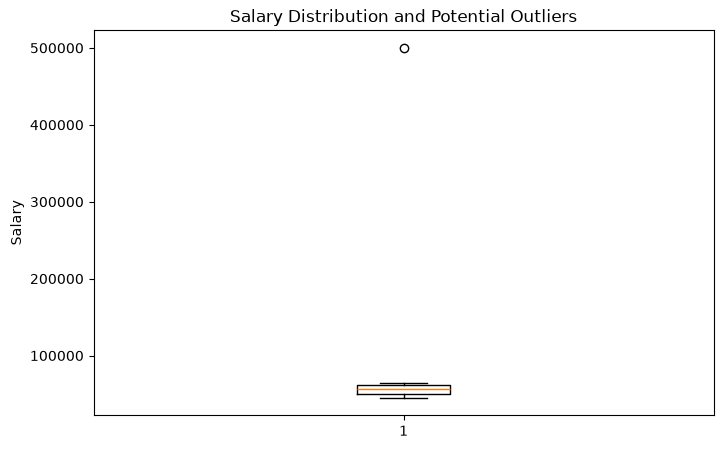

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["salary"])
plt.ylabel("Salary")
plt.title("Salary Distribution and Potential Outliers")
plt.show()

<a id="sec-18"></a>
# 15. Detecting Outliers Using Z-Score

Another common method is the **Z-score**.

The formula is:

```text
Z = (x - mean) / standard deviation
```

The Z-score tells us how many standard deviations a value is away from the mean.

A common rule is to investigate values where:

```text
abs(Z) > 3
```

The threshold should not be treated as an automatic universal rule. It depends on the data and analysis.

In [13]:
from scipy.stats import zscore

df["salary_zscore"] = zscore(df["salary"])

df

,employee,salary,salary_zscore
0,Ali,45000,-0.407821
1,Ahmed,48000,-0.385372
2,Sara,50000,-0.370406
3,John,52000,-0.355440
4,Maria,55000,-0.332992
5,David,58000,-0.310543
6,Usman,60000,-0.295577
7,Ayesha,62000,-0.280611
8,Tom,65000,-0.258162
9,Emma,500000,2.996924


<a id="sec-19"></a>
# 16. Find Z-Score Outliers

Use the absolute value of the Z-score so that both very large and very small values are detected.

In [14]:
zscore_outliers = df[df["salary_zscore"].abs() > 3]

zscore_outliers

,employee,salary,salary_zscore


<a id="sec-20"></a>
# 17. IQR vs Z-Score

| Method | Typical Use |
|---|---|
| IQR | Useful for skewed or non-normal data |
| Z-score | Often useful when data is approximately normally distributed |
| Boxplot | Quick visual inspection |
| Domain rules | When valid business or physical limits are known |

Do not choose a method only because it is popular. Understand the distribution and meaning of your data.

<a id="sec-21"></a>
# 18. Important Rule: Detection Is Not Treatment

Finding an outlier does **not** automatically mean that the value should be deleted.

An unusual value may be:

1. A data-entry error
2. A measurement error
3. A valid but rare observation
4. An important business event
5. A legitimate extreme customer
6. A value caused by a different population or process

For example, a salary of `500000` may be an error in one dataset, but it may be completely legitimate for a senior executive in another dataset.

Always investigate the reason before removing a value.

<a id="sec-22"></a>
# 19. Treatment Method 1 — Remove Outliers

If investigation confirms that the outliers should not be part of the analysis, they can be removed.

We can create a clean DataFrame containing only values within the IQR boundaries.

In [15]:
df_clean = df[
    (df["salary"] >= lower_bound) &
    (df["salary"] <= upper_bound)
].copy()

df_clean

,employee,salary,salary_zscore
0,Ali,45000,-0.407821
1,Ahmed,48000,-0.385372
2,Sara,50000,-0.370406
3,John,52000,-0.355440
4,Maria,55000,-0.332992
5,David,58000,-0.310543
6,Usman,60000,-0.295577
7,Ayesha,62000,-0.280611
8,Tom,65000,-0.258162


<a id="sec-23"></a>
# 20. Treatment Method 2 — Replace Outliers with NaN

Sometimes we do not want to remove the entire row.

Instead, we can replace only the suspicious value with `NaN` and then apply missing-value treatment.

In [16]:
df_nan = df.copy()

mask = (
    (df_nan["salary"] < lower_bound) |
    (df_nan["salary"] > upper_bound)
)

df_nan.loc[mask, "salary"] = np.nan

df_nan

,employee,salary,salary_zscore
0,Ali,45000.0,-0.407821
1,Ahmed,48000.0,-0.385372
2,Sara,50000.0,-0.370406
3,John,52000.0,-0.355440
4,Maria,55000.0,-0.332992
5,David,58000.0,-0.310543
6,Usman,60000.0,-0.295577
7,Ayesha,62000.0,-0.280611
8,Tom,65000.0,-0.258162
9,Emma,NaN,2.996924


<a id="sec-24"></a>
# 21. Treatment Method 3 — Replace Outliers with the Median

After replacing outliers with `NaN`, we can fill the missing value using the median.

The median is often preferred over the mean when extreme values exist because the median is less sensitive to extreme observations.

In [17]:
median_salary = df_nan["salary"].median()

df_nan["salary"] = df_nan["salary"].fillna(median_salary)

df_nan

,employee,salary,salary_zscore
0,Ali,45000.0,-0.407821
1,Ahmed,48000.0,-0.385372
2,Sara,50000.0,-0.370406
3,John,52000.0,-0.355440
4,Maria,55000.0,-0.332992
5,David,58000.0,-0.310543
6,Usman,60000.0,-0.295577
7,Ayesha,62000.0,-0.280611
8,Tom,65000.0,-0.258162
9,Emma,55000.0,2.996924


<a id="sec-25"></a>
# 22. Treatment Method 4 — Capping / Winsorization

Instead of deleting an outlier, we can cap it at the lower or upper boundary.

For example, if the upper boundary is `100000`, a value of `500000` can be replaced by `100000`.

Pandas provides `clip()` for this purpose.

In [18]:
df_capped = df.copy()

df_capped["salary"] = df_capped["salary"].clip(
    lower=lower_bound,
    upper=upper_bound
)

df_capped

,employee,salary,salary_zscore
0,Ali,45000,-0.407821
1,Ahmed,48000,-0.385372
2,Sara,50000,-0.370406
3,John,52000,-0.355440
4,Maria,55000,-0.332992
5,David,58000,-0.310543
6,Usman,60000,-0.295577
7,Ayesha,62000,-0.280611
8,Tom,65000,-0.258162
9,Emma,78000,2.996924


<a id="sec-26"></a>
# 23. Compare Original and Capped Values

It is useful to keep the original column and create a new transformed column so that we can compare them.

In [19]:
df_compare = df.copy()

df_compare["salary_capped"] = df_compare["salary"].clip(
    lower=lower_bound,
    upper=upper_bound
)

df_compare[["employee", "salary", "salary_capped"]]

,employee,salary,salary_capped
0,Ali,45000,45000
1,Ahmed,48000,48000
2,Sara,50000,50000
3,John,52000,52000
4,Maria,55000,55000
5,David,58000,58000
6,Usman,60000,60000
7,Ayesha,62000,62000
8,Tom,65000,65000
9,Emma,500000,78000


<a id="sec-27"></a>
# 24. Treatment Method 5 — Log Transformation

Some variables have strong right skew because a small number of observations are very large.

A logarithmic transformation can reduce the influence of large values.

For data that may contain zero, `np.log1p()` is convenient because it calculates:

```text
log(1 + x)
```

Common examples include:

- Income
- Sales
- Transaction amounts
- Website traffic
- Population

In [20]:
df_log = df.copy()

df_log["salary_log"] = np.log1p(df_log["salary"])

df_log[["salary", "salary_log"]]

,salary,salary_log
0,45000,10.714440
1,48000,10.778977
2,50000,10.819798
3,52000,10.859018
4,55000,10.915107
5,58000,10.968216
6,60000,11.002117
7,62000,11.034906
8,65000,11.082158
9,500000,13.122365


<a id="sec-28"></a>
# 25. Compare Mean Before and After Treatment

One useful exercise is to compare the mean before and after removing or capping outliers.

In [21]:
original_mean = df["salary"].mean()
clean_mean = df_clean["salary"].mean()
capped_mean = df_capped["salary"].mean()

print("Original mean:", original_mean)
print("Mean after removing outliers:", clean_mean)
print("Mean after capping outliers:", capped_mean)

Original mean: 99500.0
Mean after removing outliers: 55000.0
Mean after capping outliers: 57300.0


<a id="sec-29"></a>
# 26. Compare Median Before and After Treatment

The median is generally much less sensitive to extreme values than the mean.

In [22]:
original_median = df["salary"].median()
clean_median = df_clean["salary"].median()
capped_median = df_capped["salary"].median()

print("Original median:", original_median)
print("Median after removing outliers:", clean_median)
print("Median after capping:", capped_median)

Original median: 56500.0
Median after removing outliers: 55000.0
Median after capping: 56500.0


<a id="sec-30"></a>
# 27. Boxplot Before and After Treatment

Create a boxplot for the original salary values and another for the treated values.

This allows you to visually understand how treatment changes the distribution.

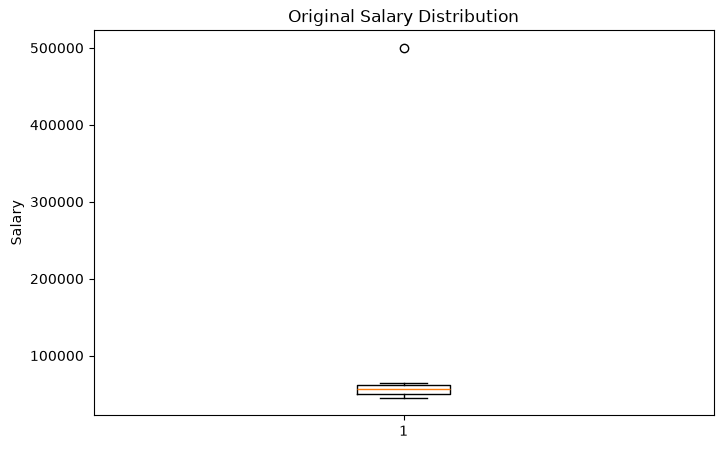

In [23]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["salary"])
plt.ylabel("Salary")
plt.title("Original Salary Distribution")
plt.show()

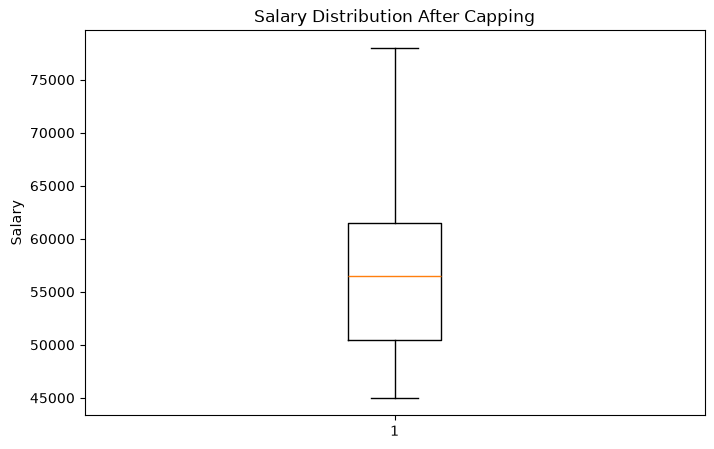

In [24]:
plt.figure(figsize=(8, 5))

plt.boxplot(df_capped["salary"])
plt.ylabel("Salary")
plt.title("Salary Distribution After Capping")
plt.show()

<a id="sec-31"></a>
# 28. Detect Outliers in Multiple Columns

Real-world DataFrames usually contain multiple numerical columns.

Example dataset:

In [25]:
employees = pd.DataFrame({
    "employee": [
        "Ali", "Ahmed", "Sara", "John", "Maria",
        "David", "Usman", "Ayesha", "Tom", "Emma"
    ],
    "age": [22, 24, 25, 27, 29, 31, 33, 35, 37, 120],
    "salary": [45000, 48000, 50000, 52000, 55000, 58000, 60000, 62000, 65000, 500000],
    "experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 50]
})

employees

,employee,age,salary,experience
0,Ali,22,45000,1
1,Ahmed,24,48000,2
2,Sara,25,50000,3
3,John,27,52000,4
4,Maria,29,55000,5
5,David,31,58000,6
6,Usman,33,60000,7
7,Ayesha,35,62000,8
8,Tom,37,65000,9
9,Emma,120,500000,50


<a id="sec-32"></a>
# 29. Identify Numerical Columns

We can use `select_dtypes()` to find numerical columns.

In [26]:
numeric_columns = employees.select_dtypes(include="number").columns

print(numeric_columns)

Index(['age', 'salary', 'experience'], dtype='str')


<a id="sec-33"></a>
# 30. Detect IQR Outliers Across All Numerical Columns

We can loop through numerical columns and calculate the IQR boundaries for each column.

In [27]:
for column in numeric_columns:
    Q1 = employees[column].quantile(0.25)
    Q3 = employees[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (
        (employees[column] < lower) |
        (employees[column] > upper)
    )

    print("Column:", column)
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Outliers:", employees.loc[mask, column].tolist())
    print("-" * 40)

Column: age
Lower bound: 12.0
Upper bound: 48.0
Outliers: [120]
----------------------------------------
Column: salary
Lower bound: 34000.0
Upper bound: 78000.0
Outliers: [500000]
----------------------------------------
Column: experience
Lower bound: -3.5
Upper bound: 14.5
Outliers: [50]
----------------------------------------


<a id="sec-34"></a>
# 31. Create a Reusable IQR Outlier Function

Reusable functions make data-cleaning code easier to maintain.

In [28]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    return {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "mask": mask,
        "outliers": df.loc[mask]
    }

<a id="sec-35"></a>
# 32. Use the Reusable Function

In [29]:
salary_result = detect_outliers_iqr(employees, "salary")

print("Q1:", salary_result["Q1"])
print("Q3:", salary_result["Q3"])
print("IQR:", salary_result["IQR"])
print("Lower bound:", salary_result["lower_bound"])
print("Upper bound:", salary_result["upper_bound"])

print("\nOutliers:")
print(salary_result["outliers"])

Q1: 50500.0
Q3: 61500.0
IQR: 11000.0
Lower bound: 34000.0
Upper bound: 78000.0

Outliers:
  employee  age  salary  experience
9     Emma  120  500000          50


<a id="sec-36"></a>
# 33. Create a Function to Return Only the Outlier Values

Sometimes we only need the values instead of the entire DataFrame.

In [30]:
def get_outlier_values(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[column] < lower) | (df[column] > upper)

    return df.loc[mask, column]

In [31]:
print(get_outlier_values(employees, "age"))
print()
print(get_outlier_values(employees, "salary"))
print()
print(get_outlier_values(employees, "experience"))

9    120
Name: age, dtype: int64

9    500000
Name: salary, dtype: int64

9    50
Name: experience, dtype: int64


<a id="sec-37"></a>
# 34. Domain-Based Outlier Detection

Statistical rules are not always the best way to detect invalid values.

Sometimes the domain itself tells us what is valid.

For example, if a DataFrame contains human age, you might define a business rule such as:

```python
age < 0
```

or values beyond a reasonable domain range can be investigated.

Similarly:

- Quantity cannot normally be negative
- Percentage may be restricted to a specific range
- Rating may be restricted to 1–5
- Exam score may be restricted to 0–100

Domain rules should be based on the actual meaning of the variable.

<a id="sec-38"></a>
# 35. Combining Statistical and Domain Rules

In real projects, you may combine:

- Statistical detection
- Business rules
- Data validation
- Visualization
- Expert/domain knowledge

For example, a salary value might be statistically unusual but still valid. A negative salary might be invalid regardless of whether it is statistically unusual.

> ✍️ **Practice time:** 36. Practice Problem 1 — Basic IQR Detection, 37. Practice Problem 2 — Boxplot, 38. Practice Problem 3 — Outlier Percentage, 39. Practice Problem 4 — Remove Outliers, 40. Practice Problem 5 — Median Replacement, 41. Practice Problem 6 — Capping Outliers … (+5 more) — open [Topic_05_Practice_Solutions.ipynb](Topic_05_Practice_Solutions.ipynb) to solve it and see the solution.

# 46b. Advanced — Multivariate and Model-Based Outlier Detection (FIX-2026-09-27)

Section 3.2 described **multivariate outliers**: rows whose values look normal **one column at a time**, but whose **combination** is unusual.
IQR and z-score look at a single column, so they miss them. Two practical tools from scikit-learn look at all columns together:

| Method | Idea | Key parameter |
|---|---|---|
| **IsolationForest** | Randomly splits the data; unusual points get **isolated in very few splits** | `contamination` = expected share of outliers |
| **LocalOutlierFactor (LOF)** | Compares each point's **local density** with its neighbours' density | `n_neighbors`, `contamination` |

Both return `-1` for outliers and `1` for normal rows. **Scale the features first** (Topic 4), because both use distances or split points across columns.

> 🔗 Related: robust z-score with MAD is shown in **Topic 4, Section 18**; transformations for skewed data in **Topic 13**.

age IQR outliers: 0
salary IQR outliers: 0

Rows flagged by IsolationForest / LOF:
    age   salary  iforest  lof
17   23  42600.0       -1   -1
60   24  95000.0       -1   -1


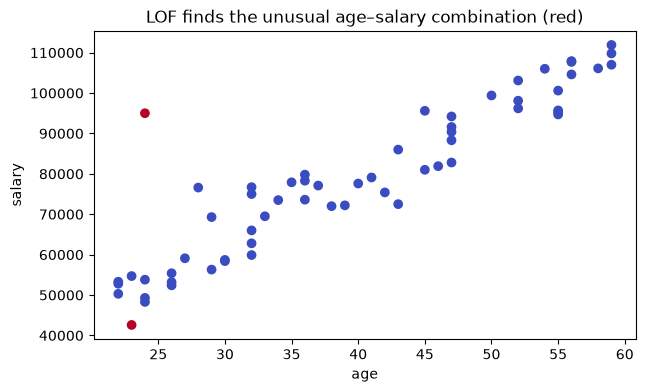

In [32]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

rng_mv = np.random.default_rng(5)
age = rng_mv.integers(22, 60, 60)
salary = 20000 + 1500 * age + rng_mv.normal(0, 6000, 60)
mv = pd.DataFrame({'age': age, 'salary': salary.round(-2)})
mv.loc[60] = [24, 95000]        # young person with a very high salary: each value alone is normal, the COMBINATION is unusual

# Univariate IQR check finds nothing unusual in either column
for col in ['age', 'salary']:
    q1, q3 = mv[col].quantile([0.25, 0.75]); iqr = q3 - q1
    print(col, 'IQR outliers:', ((mv[col] < q1 - 1.5 * iqr) | (mv[col] > q3 + 1.5 * iqr)).sum())

X_mv = StandardScaler().fit_transform(mv)
mv['iforest'] = IsolationForest(contamination=0.03, random_state=0).fit_predict(X_mv)
mv['lof'] = LocalOutlierFactor(n_neighbors=10, contamination=0.03).fit_predict(X_mv)
print('\nRows flagged by IsolationForest / LOF:')
print(mv[(mv['iforest'] == -1) | (mv['lof'] == -1)])

plt.figure(figsize=(7, 4))
plt.scatter(mv['age'], mv['salary'], c=(mv['lof'] == -1), cmap='coolwarm')
plt.title('LOF finds the unusual age–salary combination (red)')
plt.xlabel('age'); plt.ylabel('salary'); plt.show()

**Interpretation:** neither 24 years nor 95,000 is extreme on its own, so the IQR rule sees nothing. The **combination** doesn't fit the age–salary pattern, and LOF/IsolationForest flag it. (With `contamination=0.03` the models always flag about 3% of rows, so a second, borderline row is flagged too. Tune `contamination` and inspect the flagged rows.)
Use these methods for fraud detection, sensor faults, or data-quality checks across many columns, and still **investigate before removing**.

<a id="sec-39"></a>
# 47. Important Best Practices

## Best Practice 1 — Understand the Data First

Do not blindly remove every value that a statistical rule identifies.

## Best Practice 2 — Investigate the Cause

Ask whether the value is:

- Incorrect
- Missing or corrupted
- A measurement problem
- A valid rare observation
- A different population

## Best Practice 3 — Keep the Original Data

Prefer creating a new column or DataFrame instead of destroying the original data immediately.

## Best Practice 4 — Compare Before and After

Check:

- Mean
- Median
- Standard deviation
- Minimum
- Maximum
- Number of rows

## Best Practice 5 — Use Domain Knowledge

Statistical methods are tools, not replacements for understanding the business or scientific context.

<a id="sec-40"></a>
# 48. Complete Outlier-Handling Workflow

A practical workflow is:

```text
Raw Data
   ↓
Explore Data
   ↓
Understand Columns
   ↓
Visualize Distribution
   ↓
Detect Potential Outliers
   ↓
Investigate the Cause
   ↓
Choose Treatment
   ↓
Remove / Replace / Cap / Transform / Keep
   ↓
Validate Results
   ↓
Use Cleaned Data
```

The most important principle is:

> **Detecting an outlier and deciding what to do with it are separate decisions.**

<a id="sec-41"></a>
# 49. Final Revision Checklist

Before moving to the next topic, make sure you can explain and use:

- [ ] What an outlier is
- [ ] Why outliers matter
- [ ] Q1
- [ ] Q3
- [ ] IQR
- [ ] Lower bound
- [ ] Upper bound
- [ ] Boolean filtering for outliers
- [ ] Boxplots
- [ ] Z-score
- [ ] Outlier count
- [ ] Outlier percentage
- [ ] Removing outliers
- [ ] Replacing outliers with NaN
- [ ] Median replacement
- [ ] Capping with `clip()`
- [ ] Log transformation
- [ ] Multiple-column outlier detection
- [ ] Reusable functions
- [ ] Domain-based rules
- [ ] Choosing an appropriate treatment

## Final Question

**If a value is detected as an outlier, should you always remove it? Explain why or why not.**